# 06 — Interpretación y resultados (Deployment / Interpretation)

**Produce:** las tablas de perfilado en `reports/tables/` (país, variedad, procesamiento, color, numéricas de perfilado, reporte del dato, defectos y criterios de negocio), las figuras de perfilado en `reports/figures/`, el dataset plano para el tablero en `reports/dashboard/coffee_dashboard_data.csv` y el resumen de la fase en `models/interpretacion_metadata.json`.

## 6.1 Qué se hace en esta fase

Las cinco fases anteriores dejaron tres grupos de cafés que ya sabemos que son reproducibles, pero que hasta ahora solo tienen nombre de número. Esta fase los convierte en algo que se pueda contar, y son cuatro cosas:

1. **Volver a los puntos SCA.** El agrupamiento trabajó con los atributos estandarizados, o sea en desviaciones respecto al promedio, que no le dicen nada a nadie. Se revierte esa transformación con `data/processed/clustering_scaler.json` para poder decir que un grupo promedia 7.9 en aroma y no que promedia 0.8 desviaciones.
2. **Perfilar los grupos.** Cruzar cada grupo con las variables que no entraron al agrupamiento: de dónde viene el café, a qué altura se cultivó, qué variedad es, cómo se procesó y qué defectos trae.
3. **Describir cada grupo en palabras.** Un párrafo por grupo, en lenguaje llano, con un nombre que se entienda sin haber visto una sola métrica.
4. **Dejar los datos listos para el tablero.** Un archivo plano con un lote por fila, su grupo, su nombre y las columnas que el tablero va a necesitar.

Lo que no se hace acá es volver a tocar el modelo. Los grupos son los que son desde la fase 04 y ya se validaron en la fase 05; esta fase solo los lee.

## 6.2 Contexto: interpretar sin sobreinterpretar

Vale la pena arrancar por lo que la fase 05 dejó dicho, porque marca hasta dónde se puede estirar lo que viene. Los grupos son reproducibles: cambiar la semilla del algoritmo no los mueve, y quitar un 20 % de los lotes al azar tampoco. Pero no son perfectos, y hay dos números que conviene tener presentes. El primero es la silueta, que quedó en 0.43 en el espacio donde el modelo se ajustó y en 0.30 en el espacio de los siete atributos, o sea una separación moderada. El segundo es el ARI contra el corte de 80 puntos, que dio 0.18: bajo, y eso es una buena noticia mal disfrazada, porque significa que el agrupamiento encontró algo distinto de lo que ya decía la convención de la industria, en vez de reempaquetarla. El aporte del modelo es justamente ese tramo intermedio de calidad que el umbral de 80 no distingue.

La separación moderada tiene una explicación que ya venía desde la fase 04 y que cambia cómo hay que leer todo lo que sigue. Los siete atributos de catación están muy correlacionados entre sí: un café que puntúa alto en aroma tiende a puntuar alto en sabor, en acidez y en cuerpo, así que casi toda la variación entre lotes cabe en un solo eje, el de calidad general de la taza. Los tres grupos son tramos de ese eje, no nubes separadas flotando en el espacio. Eso quiere decir que las fronteras entre grupos las puso el algoritmo donde le pareció, y que un lote justo en el borde bien podría estar del otro lado. La fase 05 contó cuántos son esos lotes de borde: unos 32 de 1310.

La otra cosa que hay que tener clara antes de mirar los perfilados es qué tipo de afirmación se puede hacer con ellos. Van a aparecer diferencias reales de país y de altitud entre los grupos, y son diferencias medibles, no impresiones. Pero medir que los cafés de mayor puntaje se cultivan en promedio 250 metros más arriba no es lo mismo que demostrar que la altura los mejora. Nadie diseñó un experimento donde se sembrara el mismo café a dos alturas distintas; lo que hay son lotes que llegaron a certificarse, con su país, su variedad, su suelo, su clima, su manejo poscosecha y mil cosas más que no están en la base y que van todas juntas. Lo que se puede decir es que ciertos rasgos aparecen más en unos grupos que en otros, y eso ya es útil como guía, siempre que no se lo presente como una receta.

A esto se suma de dónde salen los datos. La base del CQI reúne lotes que buscaron una certificación de calidad, no una muestra representativa del café del mundo, y se nota: el 86 % ya supera los 80 puntos. Así que cuando acá se hable de un grupo de calidad más baja, se está hablando de calidad más baja dentro de un conjunto que de entrada ya era bueno. Y todo esto vale solo para arabica, porque robusta quedó fuera desde la fase 03 por usar otro formulario de catación y tener apenas 28 registros.

Nada de esto es un descargo de responsabilidad para curarse en salud. Un análisis sobre datos reales siempre viene con estas condiciones, y decirlas es parte del trabajo: lo que hace confiable un resultado no es que no tenga límites, sino que se sepa exactamente cuáles son.

## 6.3 Carga de artefactos y revisión de metadatos

Antes de interpretar, se revisa qué se está cargando. De la fase 03 viene `clustering_scaler.json`, con la media y la escala que se usaron para estandarizar; de la fase 04, `coffee_clustered.csv` con la columna `grupo` y los metadatos del modelo; y de la fase 05, `clustering_evaluation.json`, de donde salen las métricas de validación que se citan en el resto del notebook. Ninguna de esas cifras se escribe a mano acá: se leen del archivo, para que si alguien reejecuta una fase anterior el texto no quede desactualizado.

In [1]:
import sys
sys.path.insert(0, "..")  # para poder importar src/ desde notebooks/

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config, resolve_path
from src.visualization.plots import plot_profiling_categorical

%matplotlib inline
pd.set_option('display.max_columns', 40)
config = load_config()

# Todo lo que sea un parámetro sale del config, no del texto del notebook.
SCA_FEATURES = config['clustering']['features']                     # los 7 atributos que agruparon
PROFILING_FEATURES = config['clustering']['profiling_features']     # las que describen, sin agrupar
REFERENCE_COLUMN = config['validation']['reference_column']         # Total.Cup.Points
SPECIALTY_THRESHOLD = config['validation']['specialty_threshold']   # 80

processed = resolve_path(config['paths']['data']['processed_dir'])
models_dir = resolve_path(config['paths']['models_dir'])
figures_dir = resolve_path(config['paths']['reports']['figures_dir'])
tables_dir = resolve_path(config['paths']['reports']['tables_dir'])
dashboard_dir = resolve_path(config['paths']['reports']['dashboard_dir'])

coffee = pd.read_csv(processed / 'coffee_clustered.csv')
X_estandarizada = pd.read_csv(processed / 'clustering_input.csv')
escalador = json.loads((processed / 'clustering_scaler.json').read_text(encoding='utf-8'))
metadata = json.loads((models_dir / 'clustering_metadata.json').read_text(encoding='utf-8'))
evaluacion = json.loads((models_dir / 'clustering_evaluation.json').read_text(encoding='utf-8'))

GRUPOS = sorted(coffee['grupo'].unique())
print('Lotes con grupo asignado:', coffee.shape, '| grupos:', GRUPOS)
print('Atributos que agruparon:', SCA_FEATURES)
print('Variables de perfilado (config):', PROFILING_FEATURES)

Lotes con grupo asignado: (1310, 24) | grupos: [0, 1, 2]
Atributos que agruparon: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Cupper.Points']
Variables de perfilado (config): ['Country.of.Origin', 'altitude_mean_meters', 'Variety', 'Processing.Method', 'Color', 'Harvest.Year']


In [2]:
# Metadatos de las fases 04 y 05, tal como quedaron guardados.
print('Modelo:', metadata['representacion'], '+', metadata['algoritmo'],
      '| k =', metadata['k'], '| semilla', metadata['random_seed'])
print('Tamaño de los grupos:', metadata['tam_grupos'])
print()
print('VALIDACIÓN (fase 05)')
print('  silueta global:', metadata['silhouette'],
      '| en los 7 atributos:', evaluacion['metricas_7_atributos']['silhouette'])
print('  silueta por grupo:', evaluacion['silueta_por_grupo'])
print('  ARI medio al cambiar la semilla:', evaluacion['estabilidad_semillas']['ari_medio'])
print('  ARI medio con submuestras del',
      f"{evaluacion['estabilidad_submuestras']['subsample_fraction'] * 100:.0f} %:",
      evaluacion['estabilidad_submuestras']['ari_medio'])
print('  % de lotes que conservan su grupo, por grupo:',
      evaluacion['estabilidad_asignacion']['pct_conserva_por_grupo'])
print('  ARI contra el corte de', SPECIALTY_THRESHOLD, 'puntos:',
      evaluacion['contraste_externo']['ari_k3_vs_umbral'])

Modelo: pca_2 + kmeans | k = 3 | semilla 42
Tamaño de los grupos: {'0': 708, '1': 295, '2': 307}

VALIDACIÓN (fase 05)
  silueta global: 0.4279 | en los 7 atributos: 0.2955
  silueta por grupo: {'0': 0.452, '1': 0.422, '2': 0.379}
  ARI medio al cambiar la semilla: 0.9961
  ARI medio con submuestras del 80 %: 0.9517
  % de lotes que conservan su grupo, por grupo: {'0': 98.7, '1': 98.09, '2': 98.26}
  ARI contra el corte de 80 puntos: 0.1771


**Hallazgo.** Los artefactos cargados corresponden al modelo que se validó: `pca_2` con k-means y **k = 3**, semilla 42, y los tres grupos con **708**, **295** y **307** lotes. Las métricas que trae `clustering_evaluation.json` son las que enmarcan esta fase: silueta de **0.4279** en el espacio del modelo y **0.2955** en el de los siete atributos, ARI de **0.9961** al cambiar la semilla y de **0.9517** con submuestras del 80 %, y entre **98.09 %** y **98.7 %** de los lotes conservando su grupo según cuál sea. El ARI contra el corte de 80 puntos es **0.1771**.

Conviene fijar ese último número porque es el que sostiene todo el resto del notebook. Un ARI de 0.18 contra el umbral de la industria quiere decir que los grupos y la clasificación de especialidad se parecen poco, y por lo tanto que describir los grupos no es una forma rebuscada de repetir quién pasa de 80 puntos. Hay algo propio que contar, y eso es lo que se hace de acá en adelante.

## 6.4 Centros de los grupos en unidades reales

El agrupamiento no trabajó con los puntajes tal como los escribió el catador, sino con una versión estandarizada de ellos, donde cada atributo quedó con media 0 y desviación 1. Eso era necesario para que ningún atributo pesara de más por su escala, pero deja los centros de los grupos en unas unidades que no significan nada fuera del modelo: decir que un grupo tiene 0.8 en aroma no le sirve a un caficultor.

La vuelta atrás es directa, porque la fase 03 guardó la media y la escala de cada atributo en `clustering_scaler.json`. Con eso, cada valor estandarizado se convierte de nuevo en puntos SCA con la fórmula `valor_original = valor_estandarizado * escala + media`. Se calcula entonces el promedio de cada grupo en el espacio estandarizado, se revierte, y de paso se comprueba contra el promedio de las columnas originales de `coffee_clustered.csv`, que tienen que dar lo mismo.

In [3]:
media_original = np.array(escalador['mean'])
escala_original = np.array(escalador['scale'])

# El orden de las columnas del scaler tiene que ser el mismo de la matriz estandarizada,
# porque la reversión se hace posición por posición.
assert escalador['features'] == list(X_estandarizada.columns)

# Centro de cada grupo en el espacio estandarizado (en desviaciones respecto al promedio).
centros_estandarizados = X_estandarizada.groupby(coffee['grupo']).mean()

# Vuelta a puntos SCA: valor_original = valor_estandarizado * escala + media.
centros_puntos = centros_estandarizados * escala_original + media_original

print('Centros de los grupos en desviaciones (así los vio el algoritmo):')
print(centros_estandarizados.round(2))
print('\nCentros de los grupos en puntos SCA (así los entiende un catador):')
print(centros_puntos.round(2))

# Comprobación: tiene que coincidir con el promedio de las columnas sin estandarizar.
promedio_directo = coffee.groupby('grupo')[SCA_FEATURES].mean()
print('\n¿La reversión coincide con el promedio de las columnas originales?:',
      bool(np.allclose(centros_puntos.to_numpy(), promedio_directo.to_numpy())))

# Los grupos se ordenan por su puntaje promedio, no por su número: el algoritmo los
# numeró arbitrariamente y ese orden se reutiliza en el resto del notebook.
orden_por_calidad = centros_puntos.mean(axis=1).sort_values().index.tolist()
print('\nGrupos de menor a mayor puntaje promedio:', orden_por_calidad)
for anterior, siguiente in zip(orden_por_calidad, orden_por_calidad[1:]):
    salto = (centros_puntos.loc[siguiente] - centros_puntos.loc[anterior]).mean()
    print(f'  del grupo {anterior} al grupo {siguiente}: +{salto:.2f} puntos en promedio')

distancia_extremos = (centros_puntos.loc[orden_por_calidad[-1]]
                      - centros_puntos.loc[orden_por_calidad[0]])
print('Atributo que más separa a los grupos extremos:',
      distancia_extremos.idxmax(), round(distancia_extremos.max(), 2), 'puntos')
print('Atributo que menos los separa:',
      distancia_extremos.idxmin(), round(distancia_extremos.min(), 2), 'puntos')

Centros de los grupos en desviaciones (así los vio el algoritmo):
       Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Cupper.Points
grupo                                                                  
0       0.01    0.05        0.05    -0.03 -0.02     0.04           0.05
1      -1.05   -1.25       -1.25    -1.07 -1.03    -1.20          -1.14
2       0.99    1.09        1.09     1.10  1.02     1.06           0.98

Centros de los grupos en puntos SCA (así los entiende un catador):
       Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Cupper.Points
grupo                                                                  
0       7.57    7.54        7.42     7.53  7.52     7.54           7.52
1       7.24    7.10        6.97     7.20  7.22     7.10           7.02
2       7.88    7.90        7.78     7.89  7.82     7.89           7.92

¿La reversión coincide con el promedio de las columnas originales?: True

Grupos de menor a mayor puntaje promedio: [1, 0, 2]
  del grupo 1 al gr

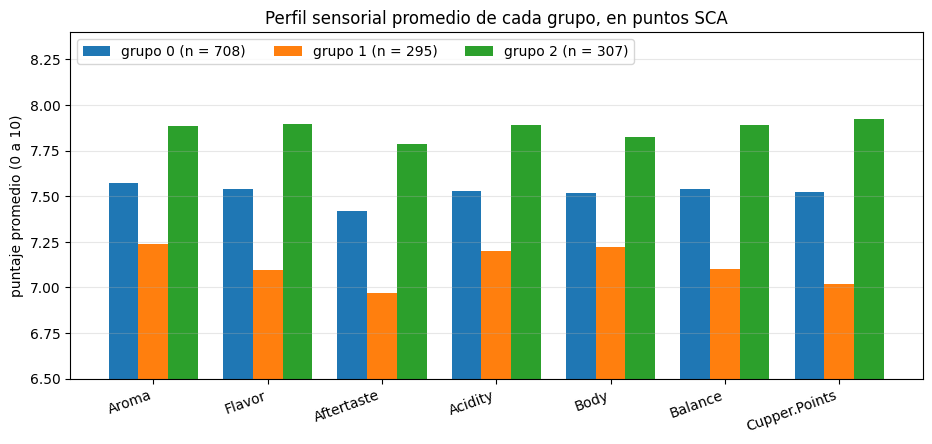

In [4]:
# Perfil sensorial de los tres grupos, en puntos SCA. Barras agrupadas para que se
# vea de un golpe que los grupos se separan por nivel y no por forma.
posiciones = np.arange(len(SCA_FEATURES))
ancho = 0.26

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, grupo in enumerate(GRUPOS):
    ax.bar(posiciones + i * ancho, centros_puntos.loc[grupo, SCA_FEATURES],
           width=ancho, label=f'grupo {grupo} (n = {len(coffee[coffee["grupo"] == grupo])})',
           color=plt.cm.tab10(grupo))
ax.set_xticks(posiciones + ancho)
ax.set_xticklabels(SCA_FEATURES, rotation=20, ha='right')
ax.set_ylabel('puntaje promedio (0 a 10)')
ax.set_ylim(6.5, 8.4)   # se recorta el eje porque toda la variación vive en esta franja
ax.set_title('Perfil sensorial promedio de cada grupo, en puntos SCA')
ax.legend(loc='upper left', ncol=3)
ax.grid(axis='y', alpha=.3)
fig.savefig(figures_dir / 'perfil_sensorial_por_grupo.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** Los tres grupos están ordenados de la misma manera en los siete atributos, sin una sola excepción. El grupo 1 va último en todo, con promedios entre **6.97** en aftertaste y **7.24** en aroma; el grupo 0 va en el medio, entre **7.42** y **7.57**; y el grupo 2 va primero en todo, entre **7.78** y **7.92**. No hay un solo atributo donde el orden se invierta, ni uno donde un grupo se despegue de su propio nivel.

Eso confirma en puntos SCA lo que la fase 04 había visto en el PCA: lo que separa a los grupos es el nivel general de la taza, no un perfil de sabor distinto. Si los grupos se diferenciaran por forma, se vería por ejemplo un grupo con mucho cuerpo y poco aroma frente a otro al revés, y las barras se cruzarían en algún punto. No se cruzan en ninguno. Las distancias entre grupos son además bastante parejas, **0.40 puntos** en promedio entre el grupo 1 y el 0, y **0.35** entre el 0 y el 2, lo que refuerza la lectura de tres tramos de una misma escala.

Vale la pena notar que el atributo donde más se abren los grupos es `Cupper.Points`, la nota global que pone el catador, y el que menos los separa es `Body`, con **0.60**. La brecha en `Cupper.Points` es de **0.91 puntos**. Tiene sentido: el cuerpo es el atributo más ligado al tipo de grano y menos a qué tan bien salió el lote, así que es el que menos sigue al eje de calidad. Es la única pista de "forma" que dan estos números, y es débil.

## 6.5 Perfilado con las variables categóricas

Acá empieza lo que la fase 01 pedía de verdad: qué tienen en común los lotes de cada grupo en cuanto a su origen y su manejo. Las variables que se cruzan son las cuatro categóricas de `config -> clustering.profiling_features`, es decir el país, la variedad, el método de procesamiento y el color del grano, ninguna de las cuales entró al agrupamiento.

Los porcentajes que se reportan son siempre **dentro de cada grupo**, no sobre el total. Es una decisión que cambia la lectura: como el grupo 0 tiene 708 lotes y el grupo 1 apenas 295, comparar conteos haría ver a México como más importante en el grupo 0 solo porque el grupo 0 es más grande. Lo que interesa es qué proporción de cada grupo ocupa cada categoría. Y hay que recordar que `Desconocido` es una categoría legítima acá: la fase 03 imputó así los faltantes de variedad, procesamiento y color, así que cuando aparece alto significa que ese grupo reportó menos, no que sus cafés sean de una variedad rara.

In [5]:
# Las categóricas salen de profiling_features, filtrando por tipo de dato en vez de
# escribir la lista otra vez.
CATEGORICAS = [c for c in PROFILING_FEATURES if coffee[c].dtype == 'object']

# Nombre de archivo de cada una (las tablas y figuras de reports/ llevan nombre en español).
ARCHIVOS = {
    'Country.of.Origin': 'paises',
    'Variety': 'variedades',
    'Processing.Method': 'procesamiento',
    'Color': 'color',
}
TOP_N = config['interpretation']['top_n_profiling']   # las tablas guardadas van completas

print('Variables categóricas de perfilado:', CATEGORICAS)
print('Categorías distintas en cada una:')
for columna in CATEGORICAS:
    print(f'  {columna:<20} {coffee[columna].nunique()} categorías')

Variables categóricas de perfilado: ['Country.of.Origin', 'Variety', 'Processing.Method', 'Color']
Categorías distintas en cada una:
  Country.of.Origin    37 categorías
  Variety              30 categorías
  Processing.Method    6 categorías
  Color                4 categorías


In [6]:
# Una tabla por variable, en formato largo: grupo, valor, conteo y % dentro del grupo.
tablas_categoricas = {}

for columna in CATEGORICAS:
    filas = []
    for grupo in GRUPOS:
        del_grupo = coffee[coffee['grupo'] == grupo]
        conteos = del_grupo[columna].value_counts()
        for valor, n in conteos.items():
            filas.append({
                'grupo': grupo,
                'valor': valor,
                'n': int(n),
                'pct_dentro_del_grupo': round(n / len(del_grupo) * 100, 1),
            })
    tablas_categoricas[columna] = pd.DataFrame(filas)

# Vista rápida: los TOP_N valores de cada grupo, variable por variable.
for columna in CATEGORICAS:
    print(f'===== {columna} =====')
    tabla = tablas_categoricas[columna]
    for grupo in GRUPOS:
        del_grupo = tabla[tabla['grupo'] == grupo].head(TOP_N)
        resumen = ', '.join(f"{fila['valor']} {fila['pct_dentro_del_grupo']} %"
                            for _, fila in del_grupo.iterrows())
        print(f'  grupo {grupo}: {resumen}')
    print()

===== Country.of.Origin =====
  grupo 0: Colombia 18.1 %, Mexico 17.4 %, Guatemala 14.0 %, Brazil 12.6 %, Taiwan 5.8 %, United States (Hawaii) 4.8 %
  grupo 1: Mexico 31.9 %, Guatemala 15.6 %, Taiwan 7.8 %, Honduras 6.4 %, Brazil 6.1 %, Nicaragua 5.8 %
  grupo 2: Colombia 15.6 %, Ethiopia 12.1 %, Guatemala 11.7 %, Brazil 8.1 %, United States (Hawaii) 8.1 %, Kenya 6.5 %

===== Variety =====
  grupo 0: Caturra 21.9 %, Bourbon 18.6 %, Typica 14.8 %, Desconocido 14.1 %, Other 6.2 %, Catuai 6.1 %
  grupo 1: Typica 28.1 %, Bourbon 17.6 %, Caturra 12.5 %, Desconocido 11.9 %, Other 10.2 %, Catuai 7.1 %
  grupo 2: Desconocido 21.5 %, Caturra 20.5 %, Bourbon 13.7 %, Other 11.1 %, Typica 7.5 %, Hawaiian Kona 4.9 %

===== Processing.Method =====
  grupo 0: Washed / Wet 62.6 %, Natural / Dry 18.8 %, Desconocido 10.7 %, Semi-washed / Semi-pulped 4.8 %, Other 2.0 %, Pulped natural / honey 1.1 %
  grupo 1: Washed / Wet 70.8 %, Natural / Dry 15.3 %, Desconocido 7.1 %, Semi-washed / Semi-pulped 3.1 %, O

In [7]:
# Conteos y porcentajes cruzados, para poder mirar una variable de un vistazo.
# (El país tiene 36 categorías, así que se muestra solo el cruce de las 8 más frecuentes.)
paises_frecuentes = coffee['Country.of.Origin'].value_counts().head(8).index
cruce_paises = pd.crosstab(coffee['grupo'],
                           coffee['Country.of.Origin'])[paises_frecuentes]
print('Conteo de lotes por grupo y país (8 países más frecuentes):')
print(cruce_paises)
# El porcentaje se calcula sobre TODOS los lotes del grupo, no sobre los 8 países
# mostrados, para que cuadre con los porcentajes de la celda anterior. Por eso las
# filas no suman 100: falta el resto de los países.
tamanos_grupo = coffee['grupo'].value_counts().sort_index()
print('\nEl mismo cruce como % del total de lotes de cada grupo:')
print((cruce_paises.div(tamanos_grupo, axis=0) * 100).round(1))

Conteo de lotes por grupo y país (8 países más frecuentes):
Country.of.Origin  Mexico  Colombia  Guatemala  Brazil  Taiwan  \
grupo                                                            
0                     123       128         99      89      41   
1                      94         7         46      18      23   
2                      19        48         36      25      11   

Country.of.Origin  United States (Hawaii)  Honduras  Costa Rica  
grupo                                                            
0                                      34        28          27  
1                                      14        19           6  
2                                      25         5          18  

El mismo cruce como % del total de lotes de cada grupo:
Country.of.Origin  Mexico  Colombia  Guatemala  Brazil  Taiwan  \
grupo                                                            
0                    17.4      18.1       14.0    12.6     5.8   
1                    31.

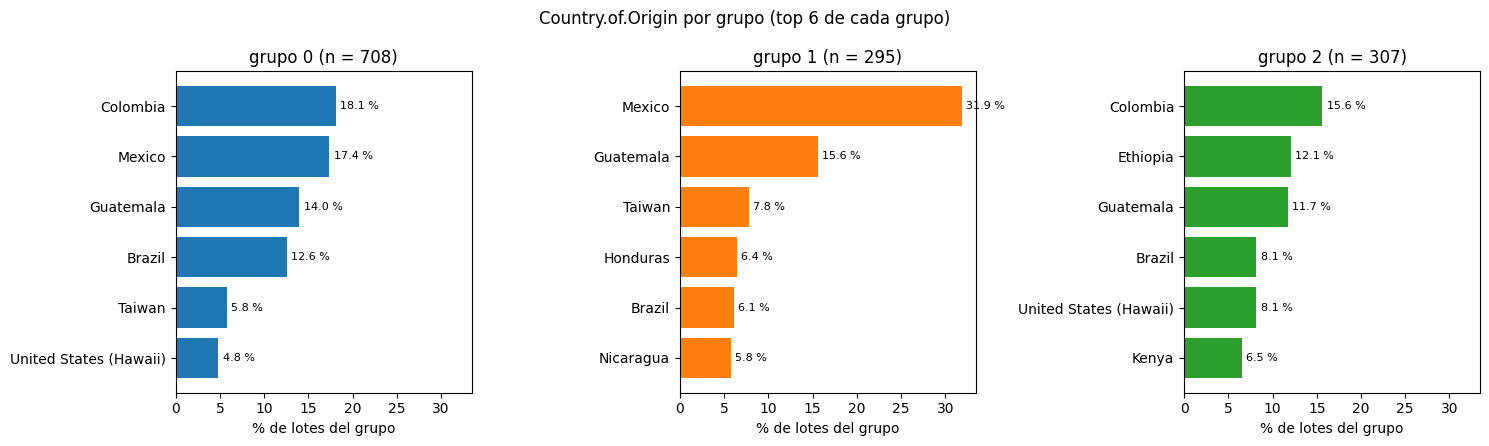

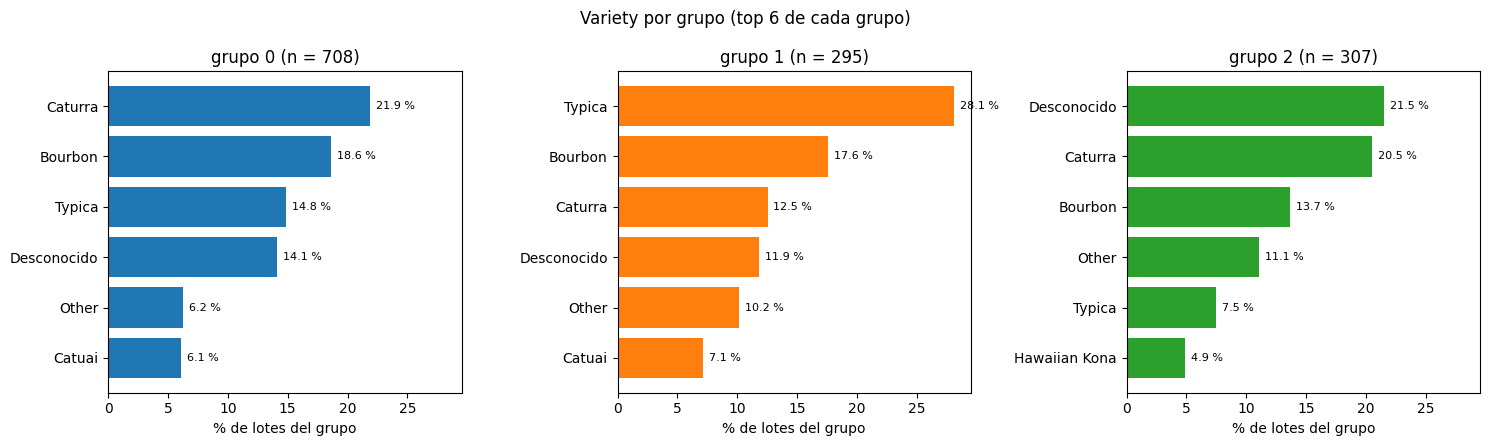

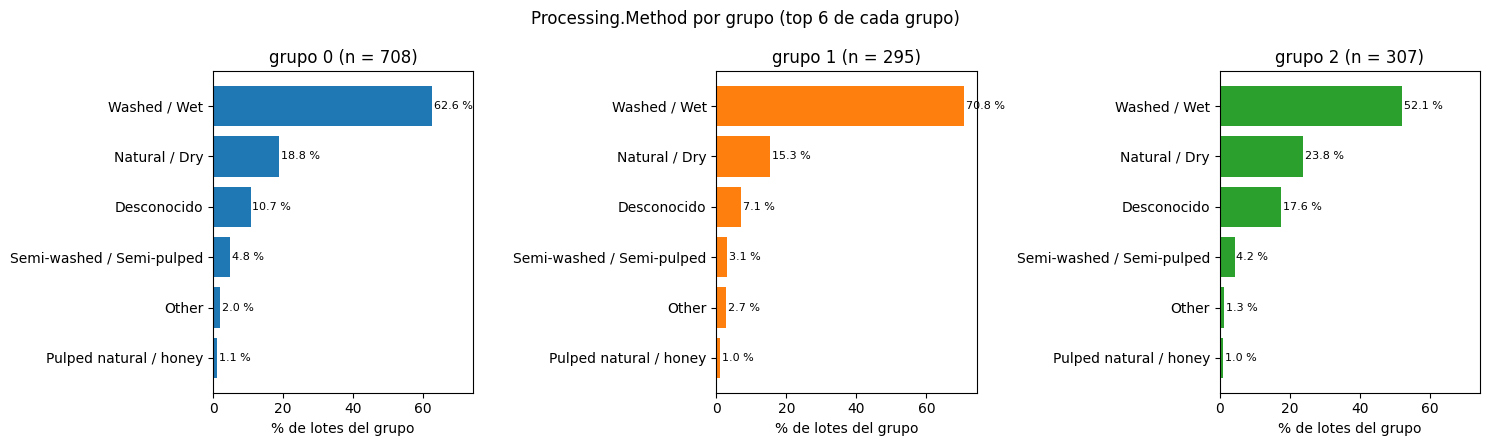

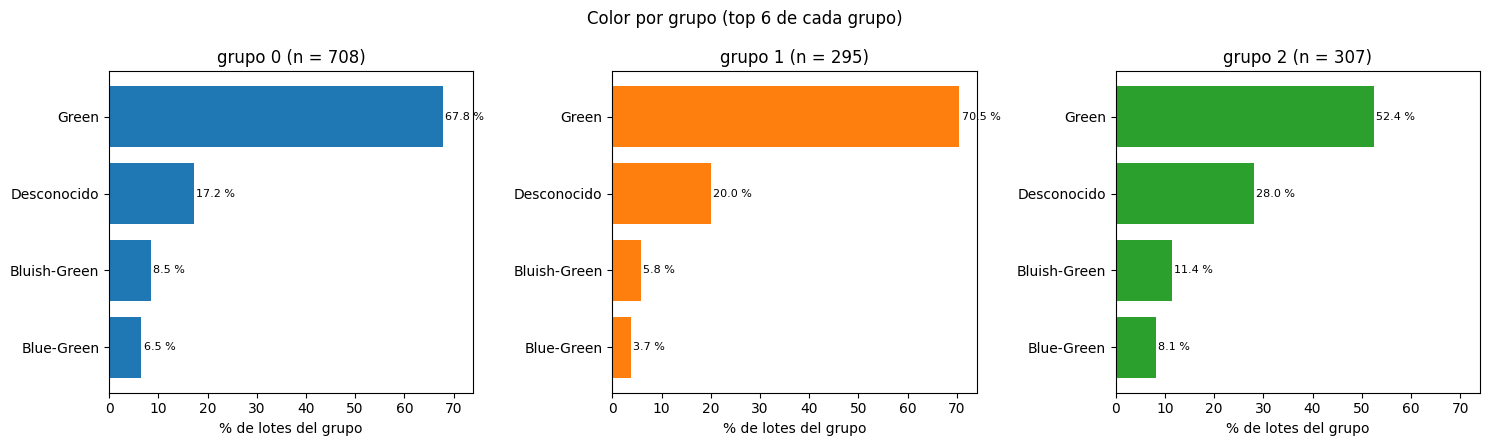

In [8]:
# Una figura por variable: un panel por grupo con sus valores más frecuentes.
for columna in CATEGORICAS:
    plot_profiling_categorical(coffee, columna, 'grupo', config,
                               f'perfilado_{ARCHIVOS[columna]}_por_grupo.png',
                               top_n=TOP_N)
    plt.show()

**Hallazgo del país.** El origen es, de lejos, la variable que más diferencia a los grupos, y hay tres casos que se leen solos. México pasa del **17.4 %** del grupo 0 al **31.9 %** del grupo 1, o sea que casi un tercio de los cafés de menor puntaje son mexicanos, y en el grupo 2 baja al **6.2 %**. Colombia hace exactamente lo contrario: es el país más frecuente tanto del grupo 0 (**18.1 %**) como del grupo 2 (**15.6 %**), y en el grupo 1 se cae al noveno puesto con **7 lotes**, un **2.4 %**. Y Etiopía y Kenia son el contraste más marcado de todos: entre las dos ocupan el **18.6 %** del grupo 2 y apenas el **0.6 %** del grupo 1, aunque en toda la base juntas no llegan al 6 % de los lotes.

Aun así, ningún país se lleva un grupo entero. El más concentrado es el grupo 1 con ese 31.9 % de México, y aun ahí dos de cada tres lotes vienen de otro lado. El país inclina la balanza pero no determina el grupo, y eso hay que decirlo con cuidado en el tablero: en esta base no existe un país de cafés malos ni uno de cafés buenos.

**Hallazgo de la variedad.** Acá aparece algo que no esperábamos. `Typica` se concentra en el grupo 1, donde ocupa el **28.1 %** frente al 14.8 % del grupo 0 y apenas el **7.5 %** del grupo 2, mientras que `Caturra` va al revés, con **21.9 %** y **20.5 %** en los grupos 0 y 2 contra **12.5 %** en el 1. Es una diferencia de proporción grande para una variable que nadie eligió al agrupar. Ahora, antes de sacar conclusiones sobre variedades hay que mirar el `Desconocido`, que en el grupo 2 es la categoría más frecuente con **21.5 %**: uno de cada cinco lotes del mejor grupo no dice qué variedad es, así que cualquier ranking de variedades en ese grupo está construido sobre el 78 % que sí reportó.

**Hallazgo del procesamiento.** El lavado domina en todas partes, que era lo esperable porque es el método de casi dos tercios de la base, pero la proporción cambia de forma ordenada: **70.8 %** en el grupo 1, **62.6 %** en el 0 y **52.1 %** en el 2. Al mismo tiempo el natural sube de **15.3 %** a **18.8 %** y a **23.8 %**. Dicho simple, entre mejor es el grupo, menos lavado y más natural hay. Es una tendencia clara y vale la pena anotarla, pero el `Desconocido` del grupo 2 vuelve a ser alto (**17.6 %**) y buena parte de esa diferencia podría estar ahí escondida.

**Hallazgo del color.** Es la variable que menos separa. `Green` es mayoría en los tres grupos (**67.8 %**, **70.5 %** y **52.4 %**) y las dos tonalidades azuladas son minoría en todos. Lo único que se mueve es, otra vez, el `Desconocido`: **28 %** en el grupo 2 contra **17.2 %** y **20 %** en los otros dos. El color del grano, tal como está registrado en esta base, no aporta para distinguir grupos.

## 6.6 Perfilado con las variables numéricas

Quedan tres variables numéricas de perfilado: la altitud de la finca, la humedad del grano y el año de cosecha. Las dos primeras vienen con una advertencia que la fase 03 dejó explícita y que hay que respetar acá: **no se imputan**. Los faltantes de altitud no son aleatorios, dependen de quién reportó y de dónde, así que rellenarlos con una mediana aplanaría justamente lo que se quiere leer. La consecuencia práctica es que cada estadística de esta sección se calcula solo con los lotes que sí reportaron el dato, y por eso la tabla lleva su propia columna `n`: no todos los grupos tienen los mismos 1310 lotes disponibles.

Dos aclaraciones sobre las unidades. `Moisture` viene en fracción y no en porcentaje, así que un valor de 0.11 es un 11 % de humedad; se deja tal cual está en la base para no transformar datos en esta fase. Y `Harvest.Year` es el año de cosecha convertido a número en la fase 03, así que su promedio se lee como "el año típico de los lotes del grupo", que sirve para descartar que un grupo sea simplemente más viejo que otro.

In [9]:
# Las numéricas de perfilado del config son la altitud y el año; `Moisture` se suma
# porque la fase 03 la dejó como variable de perfilado numérica (notebook 03, sección
# 3.11) junto con su bandera `humedad_reportada`, aunque no esté en profiling_features.
NUMERICAS = [c for c in PROFILING_FEATURES if pd.api.types.is_numeric_dtype(coffee[c])]
NUMERICAS = NUMERICAS + ['Moisture']
print('Variables numéricas de perfilado:', NUMERICAS)

filas = []
for columna in NUMERICAS:
    for grupo in GRUPOS:
        valores = coffee.loc[coffee['grupo'] == grupo, columna].dropna()
        n_grupo = int((coffee['grupo'] == grupo).sum())
        filas.append({
            'variable': columna,
            'grupo': grupo,
            'n_reporta': len(valores),          # lotes que SÍ tienen el dato
            'n_grupo': n_grupo,                 # lotes del grupo, para leer el n en contexto
            'pct_reporta': round(len(valores) / n_grupo * 100, 1),
            'media': round(valores.mean(), 2),
            'desviacion': round(valores.std(), 2),
            'minimo': round(valores.min(), 2),
            'maximo': round(valores.max(), 2),
        })
perfilado_numericas = pd.DataFrame(filas)
print()
print(perfilado_numericas.to_string(index=False))

Variables numéricas de perfilado: ['altitude_mean_meters', 'Harvest.Year', 'Moisture']

            variable  grupo  n_reporta  n_grupo  pct_reporta   media  desviacion  minimo  maximo
altitude_mean_meters      0        572      708         80.8 1343.66      348.65  350.00 2527.00
altitude_mean_meters      1        231      295         78.3 1229.71      303.05  250.00 1859.28
altitude_mean_meters      2        229      307         74.6 1478.09      375.44  250.50 2560.00
        Harvest.Year      0        673      708         95.1 2013.75        1.79 2009.00 2018.00
        Harvest.Year      1        284      295         96.3 2013.42        1.57 2009.00 2017.00
        Harvest.Year      2        290      307         94.5 2013.29        2.00 2009.00 2017.00
            Moisture      0        568      708         80.2    0.11        0.02    0.01    0.28
            Moisture      1        259      295         87.8    0.12        0.02    0.01    0.18
            Moisture      2        231 

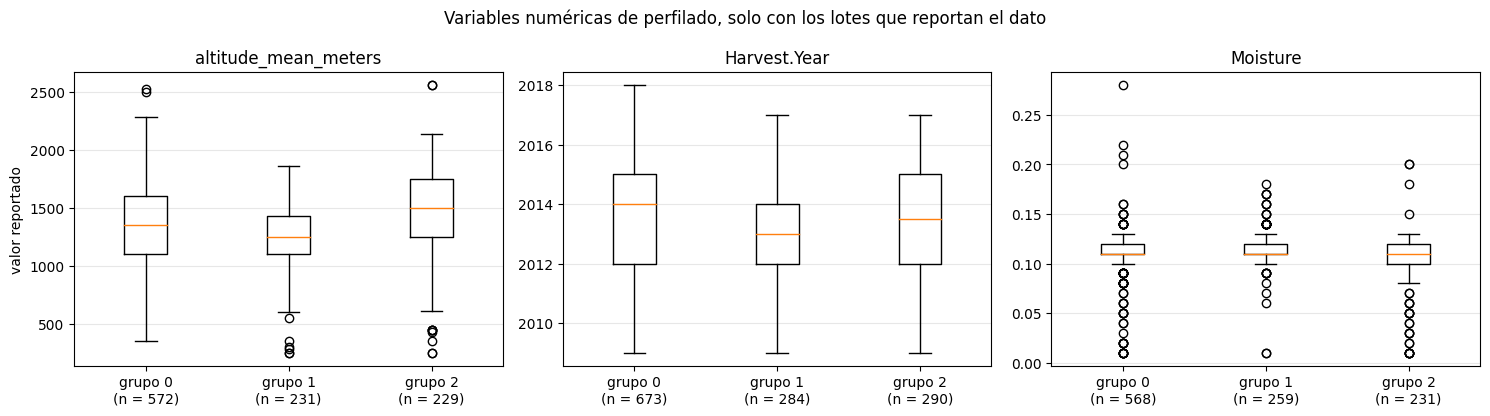

In [10]:
# Un panel por variable, con los tres grupos lado a lado. Solo entran los lotes que
# reportaron el dato, que es lo que dice la columna n_reporta de la tabla de arriba.
fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(5 * len(NUMERICAS), 4.2))
axes = np.atleast_1d(axes)

for ax, columna in zip(axes, NUMERICAS):
    datos = [coffee.loc[coffee['grupo'] == grupo, columna].dropna() for grupo in GRUPOS]
    ax.boxplot(datos, labels=[f'grupo {grupo}\n(n = {len(d)})'
                              for grupo, d in zip(GRUPOS, datos)])
    ax.set_title(columna)
    ax.grid(axis='y', alpha=.3)
axes[0].set_ylabel('valor reportado')
fig.suptitle('Variables numéricas de perfilado, solo con los lotes que reportan el dato')
fig.tight_layout()
fig.savefig(figures_dir / 'perfilado_numericas_por_grupo.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** La altitud sí separa a los grupos y lo hace en el sentido que uno esperaría: los lotes del grupo 2 se cultivan en promedio a **1478 metros**, los del grupo 0 a **1344** y los del grupo 1 a **1230**. Son **248 metros** de diferencia entre los extremos, con los tres grupos ordenados igual que sus puntajes. Ahora, el boxplot enseña lo otro que hay que decir: los rangos se solapan casi por completo. El grupo 1 llega hasta los 1859 metros y el grupo 2 arranca en 250, así que hay cafés de finca alta en el grupo de menor puntaje y viceversa. La altitud corre la distribución, no define el grupo.

La humedad casi no separa. Los promedios son **0.12** en el grupo 1, **0.11** en el 0 y **0.10** en el 2, es decir entre un 10 % y un 12 % de humedad, con desviaciones de 0.02 y 0.03 que se comen buena parte de esa diferencia. Es justo el rango normal del grano verde. Tiene sentido: la humedad se controla en el beneficio para que el café se conserve, no es un rasgo de calidad de la taza, y acá se comporta como una constante.

El año de cosecha tampoco distingue: los promedios van de **2013.29** a **2013.75** según el grupo, con el mismo rango de 2009 a 2018 en la práctica. Esto era importante descartarlo, porque si un grupo hubiera resultado sistemáticamente más viejo que otro, la diferencia de puntajes podría venir de un cambio en cómo se cataba y no del café. No es el caso.

Y queda un dato que no es sobre las variables sino sobre quién las reporta: la altitud la reporta el **80.8 %** del grupo 0, el **78.3 %** del grupo 1 y solo el **74.6 %** del grupo 2. Es una diferencia pequeña pero va en dirección contraria a lo cómodo, porque el grupo del que más nos gustaría saber la altitud es justo el que menos la reporta. Eso se mira en la sección siguiente.

## 6.7 Quién reporta y quién no

La fase 03 dejó dos banderas, `altitude_reportada` y `humedad_reportada`, que valen 1 cuando el lote trae el dato y 0 cuando no. Se crearon precisamente para poder hacer esta pregunta: ¿el hecho de no reportar está repartido al azar entre los grupos, o hay grupos que reportan menos? Si estuviera concentrado, todas las conclusiones del perfilado numérico de ese grupo estarían apoyadas en una porción sesgada de sus lotes.

Conviene aclarar de entrada cómo se lee esto. Que un grupo reporte menos no dice nada sobre la calidad de sus cafés; dice algo sobre quién llenó el formulario. Y como el reporte lo hace quien manda el lote a certificar, lo más probable es que las diferencias entre grupos no sean de los grupos sino de los países que los componen. Por eso el cruce no se queda en el grupo: baja hasta el país.

In [11]:
BANDERAS = ['altitude_reportada', 'humedad_reportada']

filas = []
for grupo in GRUPOS:
    del_grupo = coffee[coffee['grupo'] == grupo]
    fila = {'grupo': grupo, 'n_grupo': len(del_grupo)}
    for bandera in BANDERAS:
        fila[f'{bandera}_si_pct'] = round(del_grupo[bandera].mean() * 100, 1)
        fila[f'{bandera}_no_pct'] = round((1 - del_grupo[bandera].mean()) * 100, 1)
    filas.append(fila)
reporte_por_grupo = pd.DataFrame(filas)
print('Porcentaje que reporta y que no reporta cada dato, por grupo:')
print(reporte_por_grupo.to_string(index=False))

Porcentaje que reporta y que no reporta cada dato, por grupo:
 grupo  n_grupo  altitude_reportada_si_pct  altitude_reportada_no_pct  humedad_reportada_si_pct  humedad_reportada_no_pct
     0      708                       80.8                       19.2                      80.2                      19.8
     1      295                       78.3                       21.7                      87.8                      12.2
     2      307                       74.6                       25.4                      75.2                      24.8


In [12]:
# El mismo cruce pero por país, para ver si la diferencia entre grupos viene de ahí.
paises_frecuentes = coffee['Country.of.Origin'].value_counts().head(10).index
del_pais = coffee[coffee['Country.of.Origin'].isin(paises_frecuentes)]

reporte_por_pais = (del_pais.groupby('Country.of.Origin')
                    .agg(n_lotes=('altitude_reportada', 'size'),
                         pct_reporta_altitud=('altitude_reportada', lambda s: round(s.mean() * 100, 1)),
                         pct_reporta_humedad=('humedad_reportada', lambda s: round(s.mean() * 100, 1)))
                    .sort_values('n_lotes', ascending=False))
print('Reporte del dato en los 10 países con más lotes:')
print(reporte_por_pais)

# ¿A qué grupo pertenecen los lotes del país que menos reporta la altitud?
pais_menos_reporta = reporte_por_pais['pct_reporta_altitud'].idxmin()
print(f'\nPaís que menos reporta la altitud: {pais_menos_reporta}')
print('Reparto de sus lotes entre los grupos:')
print(coffee.loc[coffee['Country.of.Origin'] == pais_menos_reporta, 'grupo']
      .value_counts().sort_index())

Reporte del dato en los 10 países con más lotes:
                              n_lotes  pct_reporta_altitud  \
Country.of.Origin                                            
Mexico                            236                 97.5   
Colombia                          183                 80.3   
Guatemala                         181                 81.8   
Brazil                            132                 68.2   
Taiwan                             75                 81.3   
United States (Hawaii)             73                  2.7   
Honduras                           52                 96.2   
Costa Rica                         51                 84.3   
Ethiopia                           44                 68.2   
Tanzania, United Republic Of       40                 90.0   

                              pct_reporta_humedad  
Country.of.Origin                                  
Mexico                                       94.1  
Colombia                                     57.9 

**Hallazgo.** Las diferencias entre grupos son chicas: la altitud la reporta entre el **74.6 %** y el **80.8 %** de los lotes según el grupo, y la humedad entre el **75.2 %** y el **87.8 %**. Ningún grupo se queda sin datos, así que las estadísticas de 6.6 se sostienen en los tres casos.

Lo interesante aparece al bajar al país, y confirma la sospecha de que esto es un asunto de origen y no de calidad. Hawái reporta la altitud en apenas el **2.7 %** de sus 73 lotes, un caso aparte frente a México, que la reporta en el **97.5 %**, u Honduras en el **96.2 %**. Y esos lotes de Hawái están cargados hacia el grupo 2: **25** de sus 73 caen ahí, o sea que Hawái solo ocupa el 8.1 % del grupo 2 pero arrastra consigo una altitud casi siempre en blanco. Ahí está buena parte de la explicación de por qué el grupo 2 es el que menos altitud reporta, y no tiene nada que ver con sus cafés.

Con la humedad pasa algo parecido pero con otro país: Colombia la reporta en solo el **57.9 %** de sus lotes, la cifra más baja de los diez países más frecuentes, y Colombia es el país principal de los grupos 0 y 2. La conclusión práctica para el tablero es que estos huecos hay que mostrarlos como lo que son, una diferencia en cómo cada origen llena el formulario de certificación, y nunca como un rasgo del grupo.

## 6.8 Perfilado con los defectos

Los defectos son la otra cara de la calidad, la física en vez de la sensorial. `Category.One.Defects` cuenta los defectos primarios, que son los graves (una piedra, un grano negro, uno agrio); `Category.Two.Defects` los secundarios, más leves y mucho más comunes; y `Quakers` los granos inmaduros que no tuestan bien. Ninguno de los tres entró al agrupamiento, así que sirven igual que el puntaje total: como una verificación externa.

La hipótesis es evidente y por eso mismo vale la pena ponerla a prueba en vez de darla por buena. Si los grupos capturaron calidad de verdad, el grupo de menor puntaje debería traer más defectos que los otros dos. Hay que mirar dos cosas distintas, eso sí: cuántos defectos trae en promedio un lote, y qué proporción de lotes trae al menos uno, porque son preguntas diferentes y la mayoría de los lotes de esta base no tiene ninguno.

In [13]:
# Los defectos no están en profiling_features, pero las fases 03 y 04 los dejaron
# listados como variables de perfilado de calidad física (notebooks 03, sección 3.11,
# y 04, sección 4.9).
DEFECTOS = ['Category.One.Defects', 'Category.Two.Defects', 'Quakers']

filas = []
for columna in DEFECTOS:
    for grupo in GRUPOS:
        valores = coffee.loc[coffee['grupo'] == grupo, columna].dropna()
        filas.append({
            'variable': columna,
            'grupo': grupo,
            'n': len(valores),
            'media': round(valores.mean(), 2),
            'mediana': round(valores.median(), 2),
            'minimo': round(valores.min(), 2),
            'maximo': round(valores.max(), 2),
            'pct_con_al_menos_uno': round((valores > 0).mean() * 100, 1),
        })
perfilado_defectos = pd.DataFrame(filas)
print(perfilado_defectos.to_string(index=False))

            variable  grupo   n  media  mediana  minimo  maximo  pct_con_al_menos_uno
Category.One.Defects      0 708   0.40      0.0     0.0    31.0                  13.6
Category.One.Defects      1 295   0.61      0.0     0.0    23.0                  21.4
Category.One.Defects      2 307   0.30      0.0     0.0    10.0                  13.4
Category.Two.Defects      0 708   3.09      2.0     0.0    47.0                  70.8
Category.Two.Defects      1 295   5.71      3.0     0.0    55.0                  78.3
Category.Two.Defects      2 307   2.72      2.0     0.0    40.0                  70.4
             Quakers      0 708   0.19      0.0     0.0     9.0                   8.6
             Quakers      1 295   0.14      0.0     0.0     8.0                   4.7
             Quakers      2 307   0.18      0.0     0.0    11.0                   6.2


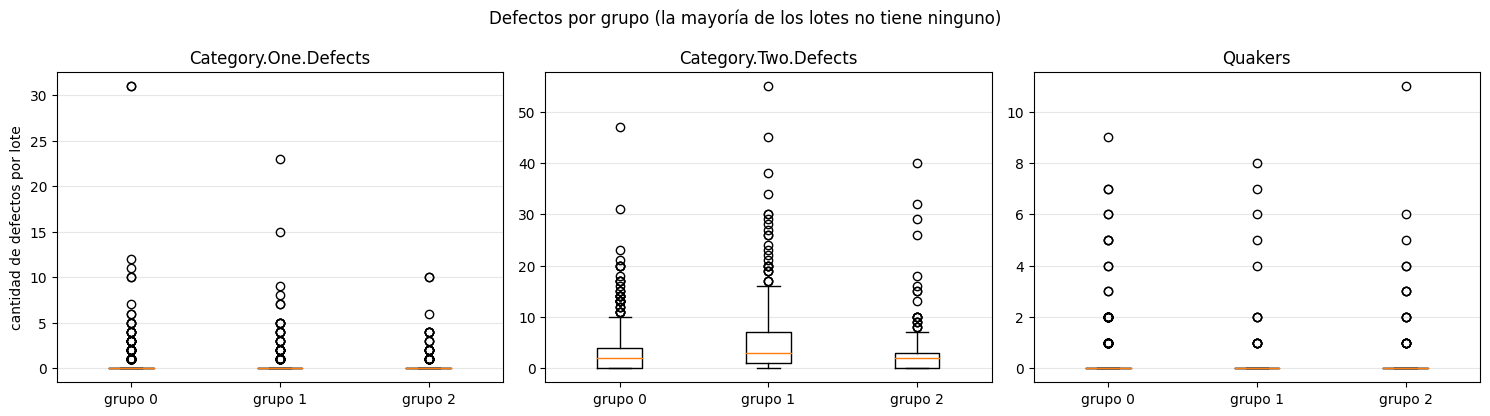

In [14]:
fig, axes = plt.subplots(1, len(DEFECTOS), figsize=(5 * len(DEFECTOS), 4.2))
axes = np.atleast_1d(axes)

for ax, columna in zip(axes, DEFECTOS):
    datos = [coffee.loc[coffee['grupo'] == grupo, columna].dropna() for grupo in GRUPOS]
    ax.boxplot(datos, labels=[f'grupo {grupo}' for grupo in GRUPOS])
    ax.set_title(columna)
    ax.grid(axis='y', alpha=.3)
axes[0].set_ylabel('cantidad de defectos por lote')
fig.suptitle('Defectos por grupo (la mayoría de los lotes no tiene ninguno)')
fig.tight_layout()
fig.savefig(figures_dir / 'perfilado_defectos_por_grupo.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** La hipótesis se cumple, y con el orden completo. En defectos de categoría dos, que son los más frecuentes, el grupo 1 promedia **5.71** por lote contra **3.09** del grupo 0 y **2.72** del grupo 2: los cafés de menor puntaje traen alrededor del doble de defectos leves que los demás. En los de categoría uno, los graves, la diferencia va en la misma dirección aunque más pequeña en promedio (**0.61** contra 0.40 y 0.30), y se ve mejor en la proporción de lotes afectados: **21.4 %** de los lotes del grupo 1 trae al menos un defecto grave, frente a un **13.6 %** y un **13.4 %** de los otros dos, que entre ellos son casi idénticos.

Que los grupos 0 y 2 empaten en defectos es tan informativo como la diferencia con el grupo 1. Lo que separa al grupo 2 del 0 es la taza, no el estado físico del grano: los dos llegan igual de limpios al catador y uno puntúa mejor que el otro por cómo sabe. En cambio el grupo 1 se distingue de los dos por ambas vías a la vez, peor taza y más defectos, que es la señal de que ahí sí hay un problema de calidad y no solo una diferencia de estilo.

Los quakers son la excepción y conviene decirlo porque rompe el patrón: el grupo 1 tiene el promedio **más bajo** de los tres (**0.14** contra 0.19 y 0.18) y también la menor proporción de lotes con al menos uno (**4.7 %** contra 8.6 % y 6.2 %). O sea que los granos inmaduros no acompañan al resto de los defectos. En los boxplots todo esto se ve como cajas pegadas al cero con colas largas, porque la mediana de los tres grupos es 0 en categoría uno y en quakers: la diferencia entre grupos no está en el lote típico sino en cuántos lotes se van a la cola.

## 6.9 Los tres grupos de cafés, en palabras

Todo lo anterior son tablas. Esta sección es la traducción, y es la que se lee en voz alta cuando alguien pregunta qué encontramos. Cada grupo va con un nombre que lo describe, cuántos lotes tiene, qué puntaje sacan, de dónde vienen, a qué altura se cultivan y qué los diferencia de los otros dos. Sin métricas y sin nombres de algoritmos: si hace falta explicar qué es una silueta para entender el párrafo, el párrafo está mal escrito.

### Grupo 0: Cafés de puntaje medio, lavados y latinoamericanos

Es el grupo más grande de todos, con **708 lotes**, más de la mitad de la base. Son cafés que puntúan entre **72.8 y 84 puntos**, con un promedio de **82.4**, lo que los deja cómodamente dentro de la categoría de especialidad: el **96.6 %** pasa la marca de los 80. Vienen sobre todo de América Latina, con Colombia (18 %), México (17 %), Guatemala (14 %) y Brasil (13 %) repartiéndose casi dos tercios del grupo, y se cultivan a una altura media de **1344 metros**. Casi dos de cada tres se procesan por la vía lavada y la variedad más común es Caturra, seguida de Bourbon.

Lo que define a este grupo es que hace todo bien sin destacar en nada. Sus cafés llegan limpios al catador, con tan pocos defectos como los del mejor grupo, pero en la taza se quedan alrededor de medio punto por debajo en todos los atributos. Es el café correcto y comercializable, el que sostiene el volumen de la certificación, y si el tablero necesita un punto de referencia contra el cual comparar a los otros dos, este es.

### Grupo 1: Cafés de puntaje más bajo, de fincas bajas y con más defectos

Son **295 lotes** y es el único grupo donde la calidad flojea de verdad. Puntúan entre **59.8 y 81.3**, con un promedio de **78.9**, y es el único donde la mayoría no alcanza la marca de especialidad: solo el **47.8 %** llega a 80 puntos. Casi un tercio son mexicanos (32 %), seguidos de Guatemala (16 %), y se cultivan más abajo que los demás, a **1230 metros** en promedio. Es también el grupo donde más domina el lavado (71 %) y donde la variedad Typica es más frecuente (28 %).

Aquí sí hay dos señales apuntando al mismo lado, y por eso es el grupo más fácil de distinguir. Además de puntuar más bajo en la taza, estos cafés llegan con más problemas físicos: traen en promedio **5.7 defectos leves** por lote, casi el doble que los otros dos grupos, y uno de cada cinco tiene al menos un defecto grave. Este es el grupo al que apuntaría cualquier plan de mejora, porque buena parte de lo que lo separa de los demás no es cuestión de gusto sino de manejo del grano.

### Grupo 2: Cafés de puntaje alto, de fincas altas y orígenes variados

Son **307 lotes** y es el grupo de los cafés sobresalientes: puntúan entre **78.3 y 90.6**, con un promedio de **84.8**, y prácticamente todos, el **99.3 %**, superan los 80 puntos. Es el grupo más internacional de los tres. Colombia sigue siendo el origen más frecuente (16 %), pero aparecen con fuerza Etiopía (12 %) y Kenia (7 %), que en los otros dos grupos casi no existen, y también Hawái (8 %). Se cultivan en las fincas más altas, **1478 metros** en promedio, casi 250 más arriba que los del grupo 1.

Su rasgo más propio, además del puntaje, es cómo se procesan: es el grupo donde menos pesa el lavado (52 %) y donde más aparece el natural o seco (24 %), un método que tiende a dar tazas más dulces y frutales. Frente al grupo 0 la diferencia no está en el estado del grano, porque los dos llegan igual de limpios, sino enteramente en la taza. Un detalle que conviene tener presente al mostrarlo: es el grupo que menos información de origen reporta, con uno de cada cinco lotes sin variedad declarada y solo tres de cada cuatro con altitud, así que se conoce menos de él que de los demás.

In [15]:
# Los nombres son la única decisión editorial de esta fase: salen de leer las
# secciones 6.4 a 6.8, no de un cálculo. Viven en config -> interpretation.group_names
# para que el notebook, `src/pipeline.py` y el dashboard digan exactamente lo mismo.
NOMBRES_GRUPOS = config['interpretation']['group_names']
for grupo in GRUPOS:
    print(f'grupo {grupo}: {NOMBRES_GRUPOS[grupo]}')
print()

# Ficha resumen de cada grupo: lo mínimo que hay que poder decir de un grupo sin
# abrir ninguna otra tabla.
filas = []
for grupo in GRUPOS:
    del_grupo = coffee[coffee['grupo'] == grupo]
    altitud = del_grupo['altitude_mean_meters'].dropna()
    filas.append({
        'grupo': grupo,
        'nombre': NOMBRES_GRUPOS[grupo],
        'n_lotes': len(del_grupo),
        'puntaje_medio': round(del_grupo[REFERENCE_COLUMN].mean(), 2),
        'puntaje_min': round(del_grupo[REFERENCE_COLUMN].min(), 2),
        'puntaje_max': round(del_grupo[REFERENCE_COLUMN].max(), 2),
        'pct_especialidad': round((del_grupo[REFERENCE_COLUMN] >= SPECIALTY_THRESHOLD).mean() * 100, 1),
        'pais_principal': del_grupo['Country.of.Origin'].value_counts().index[0],
        'altitud_media': round(altitud.mean(), 0),
        'procesamiento_principal': del_grupo['Processing.Method'].value_counts().index[0],
        'defectos_cat2_medios': round(del_grupo['Category.Two.Defects'].mean(), 2),
    })
ficha_grupos = pd.DataFrame(filas)
print(ficha_grupos.to_string(index=False))

grupo 0: Cafés de puntaje medio, lavados y latinoamericanos
grupo 1: Cafés de puntaje más bajo, de fincas bajas y con más defectos
grupo 2: Cafés de puntaje alto, de fincas altas y orígenes variados

 grupo                                                        nombre  n_lotes  puntaje_medio  puntaje_min  puntaje_max  pct_especialidad pais_principal  altitud_media procesamiento_principal  defectos_cat2_medios
     0            Cafés de puntaje medio, lavados y latinoamericanos      708          82.41        72.83        84.00              96.6       Colombia         1344.0            Washed / Wet                  3.09
     1 Cafés de puntaje más bajo, de fincas bajas y con más defectos      295          78.89        59.83        81.25              47.8         Mexico         1230.0            Washed / Wet                  5.71
     2    Cafés de puntaje alto, de fincas altas y orígenes variados      307          84.80        78.33        90.58              99.3       Colombia         1

## 6.10 Revisión de los criterios de negocio de la fase 01

La fase 01 escribió el criterio de éxito de negocio así: el proyecto es exitoso si logra señalar, con respaldo cuantitativo, qué condiciones de origen y manejo se asocian con los grupos de mejor calidad, de forma lo suficientemente clara como para servir de guía a decisiones del sector cafetero, y si el dashboard logra comunicar esos hallazgos a una audiencia no técnica. Son varias exigencias metidas en una sola frase, así que se separan y se revisa cada una contra lo que efectivamente salió. La fase 05 ya había hecho lo mismo con el criterio de minería de datos.

In [16]:
criterios = [
    {
        'criterio': 'Señalar qué condiciones de origen se asocian con los grupos de mejor calidad',
        'resultado': 'El país y la altitud separan a los grupos de forma medible y ordenada',
        'estado': 'Se cumple',
        'evidencia': ('Colombia 18.1 % del grupo 0 y 15.6 % del grupo 2 frente a 2.4 % del grupo 1; '
                      'Etiopía y Kenia 18.6 % del grupo 2 y 0.6 % del grupo 1; '
                      'altitud media de 1478 m, 1344 m y 1230 m'),
    },
    {
        'criterio': 'Señalar qué condiciones de manejo se asocian con los grupos de mejor calidad',
        'resultado': 'Hay una tendencia clara en el procesamiento y en los defectos, con la variedad menos concluyente',
        'estado': 'Se cumple parcialmente',
        'evidencia': ('Lavado 70.8 %, 62.6 % y 52.1 % del grupo 1 al 2 y natural 15.3 % a 23.8 %; '
                      'defectos de categoría dos 5.71 en el grupo 1 contra 3.09 y 2.72; '
                      'pero 21.5 % del grupo 2 no reporta variedad y 17.6 % no reporta procesamiento'),
    },
    {
        'criterio': 'Con respaldo cuantitativo',
        'resultado': 'Los grupos se validaron antes de interpretarlos y las diferencias salen de tablas, no de impresiones',
        'estado': 'Se cumple',
        'evidencia': ('Silueta 0.4279, ARI 0.9961 al cambiar la semilla y 0.9517 con submuestras del 80 %, '
                      '98.4 % de los lotes conserva su grupo (fase 05)'),
    },
    {
        'criterio': 'De forma clara para guiar decisiones del sector cafetero',
        'resultado': 'Los grupos se describen en lenguaje llano y con un nombre propio, pero son asociaciones y no relaciones de causa',
        'estado': 'Se cumple parcialmente',
        'evidencia': ('Tres descripciones en la sección 6.9; los rangos de altitud se solapan entre grupos '
                      '(el grupo 1 llega a 1859 m y el grupo 2 arranca en 250 m), así que no hay una regla de decisión'),
    },
    {
        'criterio': 'El dashboard comunica los hallazgos a una audiencia no técnica',
        'resultado': 'Queda listo el dataset plano que lo alimenta, pero el tablero se construye fuera de este repositorio',
        'estado': 'No se cumple todavía',
        'evidencia': 'reports/dashboard/coffee_dashboard_data.csv con 1310 lotes y las columnas de perfilado',
    },
]
criterios_negocio = pd.DataFrame(criterios)
for _, fila in criterios_negocio.iterrows():
    print(f"[{fila['estado']}] {fila['criterio']}")
    print(f"    {fila['resultado']}")
    print(f"    evidencia: {fila['evidencia']}\n")

[Se cumple] Señalar qué condiciones de origen se asocian con los grupos de mejor calidad
    El país y la altitud separan a los grupos de forma medible y ordenada
    evidencia: Colombia 18.1 % del grupo 0 y 15.6 % del grupo 2 frente a 2.4 % del grupo 1; Etiopía y Kenia 18.6 % del grupo 2 y 0.6 % del grupo 1; altitud media de 1478 m, 1344 m y 1230 m

[Se cumple parcialmente] Señalar qué condiciones de manejo se asocian con los grupos de mejor calidad
    Hay una tendencia clara en el procesamiento y en los defectos, con la variedad menos concluyente
    evidencia: Lavado 70.8 %, 62.6 % y 52.1 % del grupo 1 al 2 y natural 15.3 % a 23.8 %; defectos de categoría dos 5.71 en el grupo 1 contra 3.09 y 2.72; pero 21.5 % del grupo 2 no reporta variedad y 17.6 % no reporta procesamiento

[Se cumple] Con respaldo cuantitativo
    Los grupos se validaron antes de interpretarlos y las diferencias salen de tablas, no de impresiones
    evidencia: Silueta 0.4279, ARI 0.9961 al cambiar la semilla y 0

**Hallazgo.** De las cinco exigencias, dos se cumplen, dos se cumplen a medias y una no se cumple todavía. Las que se cumplen limpio son las dos que dependían del análisis: hay diferencias de origen medibles entre los grupos, y están respaldadas por una validación que se hizo antes de interpretar nada.

Las dos parciales lo son por razones distintas y vale la pena no mezclarlas. La del manejo es parcial por un problema de datos: la tendencia del procesamiento existe y es ordenada, pero justo el grupo donde es más marcada es el que más campos deja en blanco, así que no se puede afirmar con la misma fuerza que lo del país. La de servir de guía es parcial por un problema de fondo, y es el más importante de todo el proyecto: los rangos de altitud de los tres grupos se solapan casi por completo, así que de acá no sale una regla del tipo "siembre por encima de tal altura y su café pasará de 80 puntos". Lo que sale es un mapa de qué se parece a qué, que es menos de lo que un productor querría pero es lo que los datos aguantan.

La que no se cumple es la del tablero, y es simplemente porque todavía no existe: esta fase deja el archivo que lo alimenta y la descripción de qué debería mostrar, pero el tablero se arma en Power BI o Tableau, por fuera del repositorio. Es la única tarea que queda abierta del proyecto.

## 6.11 Cautelas al interpretar

Estas cinco cosas hay que tenerlas presentes cada vez que se cite un resultado de esta fase. No son un descargo: son las condiciones bajo las cuales lo anterior es cierto.

**De dónde salen los lotes.** La base del CQI reúne cafés que fueron enviados a certificar, no una muestra del café que se produce en el mundo. Se nota en que el **86.3 %** ya supera los 80 puntos antes de que nosotros hiciéramos nada. Eso significa que el grupo 1 no es "café malo": es el tramo más bajo de un conjunto que de entrada ya estaba por encima del promedio mundial, y varios de sus lotes igual son de especialidad. Cualquier lectura del tipo "estos son los cafés de mala calidad" se estaría inventando una escala que estos datos no tienen.

**Asociación no es causa.** Que el grupo 2 tenga más Colombia, más Etiopía y 250 metros más de altura no significa que sembrar en Colombia a esa altura produzca mejor café. Lo que hay son lotes que llegaron a certificarse, cada uno con su suelo, su clima, su variedad, su manejo poscosecha, su transporte y el catador que le tocó, todo junto y sin separar. Nadie sembró el mismo café a dos alturas distintas para comparar. Los perfilados de esta fase describen con qué viene acompañado cada grupo, no qué lo causó.

**Los grupos son tramos de una misma escala.** Los siete atributos de catación están tan correlacionados entre sí que casi toda la variación entre lotes cabe en un solo eje, el de calidad general de la taza. Eso se vio en 6.4, donde los tres grupos quedaron ordenados igual en los siete atributos sin una sola excepción. La consecuencia es que los grupos no son nubes separadas sino tres tramos de un continuo, las fronteras entre ellos las puso el algoritmo, y un lote que está justo en el borde perfectamente podría haber caído del otro lado. Por eso la silueta es moderada (**0.43**, y **0.30** en el espacio de los siete atributos), y por eso conviene presentar los grupos como niveles y no como categorías cerradas.

**Solo arabica.** Robusta quedó fuera desde la fase 03 porque se cata con otro formulario, con atributos que ni siquiera existen en arabica, y porque aportaba 28 registros con mucha información faltante. Todo lo de este notebook vale para arabica y para nada más.

**Reproducible no es definitivo.** Los grupos aguantan que se cambie la semilla del algoritmo (ARI de **0.9961**) y que se les quite un 20 % de los lotes al azar (ARI de **0.9517**, con entre el **98.09 %** y el **98.7 %** de los lotes conservando su grupo). Eso es lo que se puede afirmar: que el resultado es estable con estos datos y este algoritmo. No dice que tres sea el número verdadero de perfiles de café que existen, ni que otro método hubiera encontrado lo mismo. Es una descripción útil y repetible, no una verdad del mundo.

## 6.12 Exportación para el tablero

El tablero se construye por fuera de este repositorio, en Power BI o Tableau, así que lo que hace esta sección es dejarle el archivo listo. La idea es que quien lo arme no tenga que abrir un notebook ni entender el modelo: abre un CSV donde cada fila es un lote de café, ya con su grupo asignado y con las columnas que va a necesitar para filtrar y agrupar.

Además de lo que ya trae `coffee_clustered.csv`, se agregan tres columnas calculadas. La primera es `especialidad`, que vale 1 cuando el lote supera los 80 puntos, para poder cruzar el criterio de la industria con los grupos sin tener que escribir la condición en el tablero. La segunda es `grupo_nombre`, el nombre en palabras de la sección 6.9, porque nadie fuera de este proyecto sabe qué es el grupo 2. Y la tercera es `rango_puntaje`, que parte los puntajes en cuatro tramos anclados en el umbral de 80: dos por debajo y dos por encima, de cuatro puntos de ancho, que es más o menos la distancia que separa a los promedios de los grupos extremos. Tanto los nombres como el ancho de los tramos salen de `config -> interpretation`, no del código del notebook.

In [17]:
dashboard = coffee.copy()

# 1) La convención de la industria, como columna, para poder cruzarla con los grupos.
dashboard['especialidad'] = (dashboard[REFERENCE_COLUMN] >= SPECIALTY_THRESHOLD).astype(int)

# 2) El nombre del grupo, que es lo que va a leer quien mire el tablero.
dashboard['grupo_nombre'] = dashboard['grupo'].map(NOMBRES_GRUPOS)

# 3) Tramos de puntaje anclados en el umbral del config (80), de 4 puntos de ancho:
#    dos tramos por debajo y dos por encima. No hay cortes escritos a mano: el
#    ancho sale de config -> interpretation.score_band_width.
ANCHO_TRAMO = config['interpretation']['score_band_width']
cortes = [-np.inf,
          SPECIALTY_THRESHOLD - ANCHO_TRAMO,
          SPECIALTY_THRESHOLD,
          SPECIALTY_THRESHOLD + ANCHO_TRAMO,
          np.inf]
etiquetas = [f'menos de {SPECIALTY_THRESHOLD - ANCHO_TRAMO}',
             f'{SPECIALTY_THRESHOLD - ANCHO_TRAMO} a {SPECIALTY_THRESHOLD}',
             f'{SPECIALTY_THRESHOLD} a {SPECIALTY_THRESHOLD + ANCHO_TRAMO}',
             f'más de {SPECIALTY_THRESHOLD + ANCHO_TRAMO}']
dashboard['rango_puntaje'] = pd.cut(dashboard[REFERENCE_COLUMN], bins=cortes,
                                    labels=etiquetas, right=False)

dashboard_dir.mkdir(parents=True, exist_ok=True)
dashboard.to_csv(dashboard_dir / 'coffee_dashboard_data.csv', index=False)

print('reports/dashboard/coffee_dashboard_data.csv ->', dashboard.shape)
print('Columnas:', list(dashboard.columns))
print('\nLotes por grupo y tramo de puntaje:')
print(pd.crosstab(dashboard['grupo_nombre'], dashboard['rango_puntaje']))

reports/dashboard/coffee_dashboard_data.csv -> (1310, 27)
Columnas: ['Country.of.Origin', 'Harvest.Year', 'Variety', 'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Total.Cup.Points', 'Moisture', 'Category.One.Defects', 'Quakers', 'Color', 'Category.Two.Defects', 'altitude_mean_meters', 'altitude_reportada', 'humedad_reportada', 'grupo', 'especialidad', 'grupo_nombre', 'rango_puntaje']

Lotes por grupo y tramo de puntaje:
rango_puntaje                                       menos de 76  76 a 80  \
grupo_nombre                                                               
Cafés de puntaje alto, de fincas altas y orígen...            0        2   
Cafés de puntaje medio, lavados y latinoamericanos            2       22   
Cafés de puntaje más bajo, de fincas bajas y co...           36      118   

rango_puntaje                                       80 a 84  más de 84  
grupo_nombre              

El archivo queda con **1310 filas**, una por lote, y **27 columnas**: las de origen y manejo, las de catación, el grupo, y las tres calculadas. Sirve para tres audiencias distintas sin tener que rehacerlo: quien quiera contar lotes por país y grupo, quien quiera comparar puntajes, y quien quiera revisar cuánto se parecen los grupos al corte de especialidad.

Sobre qué mostrar con esto, cuatro vistas que saldrían casi solas del archivo y que responden preguntas que alguien del sector se haría. Un mapa por país donde el tamaño de cada punto sea la cantidad de lotes y el color el grupo predominante, que responde de dónde viene cada tipo de café. Un gráfico de altitud contra puntaje total, con un punto por lote coloreado por grupo, que muestra a la vez la tendencia y el solape del que habla la sección 6.11, y que es la forma más honesta de presentar la relación entre altura y calidad. Un conjunto de barras apiladas con la composición de cada grupo por método de procesamiento y por variedad, con el `Desconocido` a la vista y no escondido. Y una tarjeta por grupo con su nombre, su cantidad de lotes, su puntaje promedio y su porcentaje de especialidad, que es la ficha de la sección 6.9 puesta en pantalla.

Lo que conviene evitar en el tablero es tan importante como lo que conviene mostrar: nada de rankings de países por calidad, porque los tamaños de muestra por país son muy dispares, y nada de presentar los grupos como categorías con frontera dura, por lo que ya se explicó del solape.

## 6.13 Guardado de artefactos

Se guardan las ocho tablas de perfilado y revisión en `reports/tables/`, y el resumen de la fase en `models/interpretacion_metadata.json`, que recoge los nombres de los grupos, sus cifras principales y el estado de cada criterio de negocio. Las figuras ya se fueron guardando en cada sección, y el archivo del tablero en la anterior. No se vuelve a escribir `clustering_evaluation.json`, que es de la fase 05 y se lee, no se toca.

In [18]:
tables_dir.mkdir(parents=True, exist_ok=True)

# 1) Las cuatro tablas de perfilado categórico (completas, no solo el top).
for columna in CATEGORICAS:
    tablas_categoricas[columna].to_csv(
        tables_dir / f'perfilado_{ARCHIVOS[columna]}_por_grupo.csv', index=False)

# 2) Numéricas de perfilado, banderas de reporte y defectos.
perfilado_numericas.to_csv(tables_dir / 'perfilado_altitud_humedad_cosecha.csv', index=False)
reporte_por_grupo.to_csv(tables_dir / 'perfilado_reporte_por_grupo.csv', index=False)
perfilado_defectos.to_csv(tables_dir / 'perfilado_defectos_por_grupo.csv', index=False)

# 3) Revisión de los criterios de negocio.
criterios_negocio.to_csv(tables_dir / 'criterios_negocio_cumplidos.csv', index=False)

for archivo in sorted(tables_dir.glob('perfilado_*.csv')) + [tables_dir / 'criterios_negocio_cumplidos.csv']:
    print(f'  {archivo.name:<45} {len(pd.read_csv(archivo)):>4} filas')

  perfilado_altitud_humedad_cosecha.csv            9 filas
  perfilado_color_por_grupo.csv                   12 filas
  perfilado_defectos_por_grupo.csv                 9 filas
  perfilado_paises_por_grupo.csv                  85 filas
  perfilado_procesamiento_por_grupo.csv           18 filas
  perfilado_reporte_por_grupo.csv                  3 filas
  perfilado_variedades_por_grupo.csv              65 filas
  criterios_negocio_cumplidos.csv                  5 filas


In [19]:
# Resumen de la fase: los nombres, las cifras de cada grupo y el estado de los criterios.
interpretacion = {
    'n_lotes': int(len(coffee)),
    'k': int(metadata['k']),
    'grupos': [],
    'validacion_heredada': {
        'silueta_pca_2': evaluacion['metricas_pca_2']['silhouette'],
        'silueta_7_atributos': evaluacion['metricas_7_atributos']['silhouette'],
        'ari_semillas': evaluacion['estabilidad_semillas']['ari_medio'],
        'ari_submuestras': evaluacion['estabilidad_submuestras']['ari_medio'],
        'pct_conserva_por_grupo': evaluacion['estabilidad_asignacion']['pct_conserva_por_grupo'],
        'ari_vs_umbral_especialidad': evaluacion['contraste_externo']['ari_k3_vs_umbral'],
    },
    'criterios_negocio': {},
}
for _, fila in ficha_grupos.iterrows():
    interpretacion['grupos'].append({
        'grupo': int(fila['grupo']),
        'nombre': fila['nombre'],
        'n_lotes': int(fila['n_lotes']),
        'puntaje_medio': float(fila['puntaje_medio']),
        'pct_especialidad': float(fila['pct_especialidad']),
        'pais_principal': fila['pais_principal'],
        'altitud_media_m': float(fila['altitud_media']),
        'procesamiento_principal': fila['procesamiento_principal'],
        'silueta': evaluacion['silueta_por_grupo'][str(fila['grupo'])],
    })
for _, fila in criterios_negocio.iterrows():
    interpretacion['criterios_negocio'][fila['criterio']] = fila['estado']

(models_dir / 'interpretacion_metadata.json').write_text(
    json.dumps(interpretacion, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(interpretacion, indent=2, ensure_ascii=False))

{
  "n_lotes": 1310,
  "k": 3,
  "grupos": [
    {
      "grupo": 0,
      "nombre": "Cafés de puntaje medio, lavados y latinoamericanos",
      "n_lotes": 708,
      "puntaje_medio": 82.41,
      "pct_especialidad": 96.6,
      "pais_principal": "Colombia",
      "altitud_media_m": 1344.0,
      "procesamiento_principal": "Washed / Wet",
      "silueta": 0.452
    },
    {
      "grupo": 1,
      "nombre": "Cafés de puntaje más bajo, de fincas bajas y con más defectos",
      "n_lotes": 295,
      "puntaje_medio": 78.89,
      "pct_especialidad": 47.8,
      "pais_principal": "Mexico",
      "altitud_media_m": 1230.0,
      "procesamiento_principal": "Washed / Wet",
      "silueta": 0.422
    },
    {
      "grupo": 2,
      "nombre": "Cafés de puntaje alto, de fincas altas y orígenes variados",
      "n_lotes": 307,
      "puntaje_medio": 84.8,
      "pct_especialidad": 99.3,
      "pais_principal": "Colombia",
      "altitud_media_m": 1478.0,
      "procesamiento_principal": "Washed

## 6.14 Qué sigue después de esta fase

El análisis termina acá. Lo que queda son tres tareas que ya no son de código.

La primera es **construir el tablero** en Power BI o Tableau a partir de `reports/dashboard/coffee_dashboard_data.csv`, con las vistas sugeridas en 6.12. Es la única exigencia de la fase 01 que sigue abierta, y cuando esté hecho hay que enlazarlo desde el README.

La segunda es **preparar la sustentación**. Las descripciones de la sección 6.9 están escritas para leerse tal cual, y la tabla de criterios de 6.10 sirve de guion para la parte incómoda de la presentación, que es explicar qué se cumplió a medias y por qué. Vale más llegar con eso resuelto que tener que improvisarlo frente a los jurados.

La tercera, si el proyecto continuara, es **traer datos que esta base no tiene**. La limitación de fondo no es el algoritmo sino lo que se puede medir: para pasar de describir a recomendar harían falta variables de manejo que aquí no están (fertilización, edad del cultivo, fecha de recolección, tiempos de fermentación) y, sobre todo, lotes que no hayan pasado por el filtro de la certificación. Con lo que hay, este es el techo.